In [1]:
from unsloth import FastLanguageModel
import torch

MODEL_ID = "unsloth/Meta-Llama-3.1-8B"  # unsloth pre-quantized

model, tok = FastLanguageModel.from_pretrained(
    model_name=MODEL_ID,
    max_seq_length=512,
    dtype=None,            # auto bf16 on Blackwell
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)  # 2x faster gen
model.eval()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.6: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 5060 Ti. Num GPUs = 1. Max memory: 15.469 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.96G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-unsloth-bnb-4bit as a legacy tokenizer.


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128004)
    (layers): ModuleList(
      (0): LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRM

In [2]:
import numpy as np

# pad token fix (Llama has none)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

def extract_representation(text, model, tokenizer, device):
    inputs = tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=512,
        add_special_tokens=True,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states  # tuple of 33
    attention_mask = inputs["attention_mask"][0]

    # exclude BOS at position 0
    content_mask = attention_mask.clone()
    content_mask[0] = 0

    pooled_layers = []
    for layer_hidden in hidden_states:
        layer = layer_hidden[0].float()  # bf16 -> fp32 for pooling
        masked = layer * content_mask.unsqueeze(-1).float()
        pooled = masked.sum(dim=0) / content_mask.sum().clamp(min=1).float()
        pooled_layers.append(pooled.cpu().numpy())

    return np.stack(pooled_layers)  # (33, 4096)

In [3]:
test_texts = [
    "cat", "bat",
    "বিড়াল", "বাদুড়",
    "The boy reads a book."
]

for t in test_texts:
    rep = extract_representation(t, model, tok, "cuda")
    print(t, rep.shape, "nan:", np.isnan(rep).any(), "range:", rep.min(), rep.max())

`use_return_dict` is deprecated! Use `return_dict` instead!
/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


cat (33, 4096) nan: False range: -17.625 20.5
bat (33, 4096) nan: False range: -25.25 23.75
বিড়াল (33, 4096) nan: False range: -13.0625 19.95139


/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


বাদুড় (33, 4096) nan: False range: -13.2375 18.70625
The boy reads a book. (33, 4096) nan: False range: -29.75 21.9375


In [4]:
import pandas as pd
from tqdm import tqdm
from pathlib import Path

REPS_DIR = Path("representations")
REPS_DIR.mkdir(exist_ok=True)

df = pd.read_csv("dyslex_probe_stimuli_clean.csv")
print("shape:", df.shape)
print(df['language'].value_counts())

def extract_split(df_split, name):
    reps = []
    for text in tqdm(df_split['word'].tolist(), desc=name):
        rep = extract_representation(text, model, tok, "cuda")
        reps.append(rep)
    return np.stack(reps)  # (N, 33, 4096)

en_df = df[df['language'] == 'english'].reset_index(drop=True)
bn_df = df[df['language'] == 'bangla'].reset_index(drop=True)

en_reps = extract_split(en_df, "english")
bn_reps = extract_split(bn_df, "bangla")

np.save(REPS_DIR / "llama_english_reps.npy", en_reps)
np.save(REPS_DIR / "llama_bangla_reps.npy", bn_reps)
en_df.to_csv(REPS_DIR / "llama_english_meta.csv", index=False)
bn_df.to_csv(REPS_DIR / "llama_bangla_meta.csv", index=False)

print("EN:", en_reps.shape, "BN:", bn_reps.shape)
print("EN nan:", np.isnan(en_reps).any(), "BN nan:", np.isnan(bn_reps).any())

shape: (440, 18)
language
english    220
bangla     220
Name: count, dtype: int64


english:   0%|          | 0/220 [00:00<?, ?it/s]/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
bangla: 100%|██████████| 220/220 [00:20<00:00, 10.66it/s]


EN: (220, 33, 4096) BN: (220, 33, 4096)
EN nan: False BN nan: False


In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import f1_score, r2_score
from tqdm import tqdm

en_reps = np.load("representations/llama_english_reps.npy")  # (220, 33, 4096)
en_meta = pd.read_csv("representations/llama_english_meta.csv")
N_LAYERS = en_reps.shape[1]  # 33

def probe_binary(X_layers, y, n_splits=5):
    """Returns list of mean F1 per layer."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    for L in range(X_layers.shape[1]):
        X = X_layers[:, L, :]
        f1s = []
        for tr, te in skf.split(X, y):
            clf = LogisticRegression(max_iter=2000, C=1.0)
            clf.fit(X[tr], y[tr])
            pred = clf.predict(X[te])
            f1s.append(f1_score(y[te], pred, average="macro"))
        results.append(np.mean(f1s))
    return np.array(results)

def probe_regression(X_layers, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    for L in range(X_layers.shape[1]):
        X = X_layers[:, L, :]
        r2s = []
        for tr, te in kf.split(X):
            reg = Ridge(alpha=1.0)
            reg.fit(X[tr], y[tr])
            r2s.append(r2_score(y[te], reg.predict(X[te])))
        results.append(np.mean(r2s))
    return np.array(results)

# Task 1: voiced_unvoiced
mask = en_meta['voiced_unvoiced'].isin(['voiced', 'unvoiced'])
y = (en_meta.loc[mask, 'voiced_unvoiced'] == 'voiced').astype(int).values
X = en_reps[mask.values]
f1_voicing = probe_binary(X, y)
print(f"voicing n={mask.sum()} peak layer={f1_voicing.argmax()} F1={f1_voicing.max():.3f}")

# Task 2: is_real_word
mask = en_meta['is_real_word'].isin([True, False, 'True', 'False'])
y = en_meta.loc[mask, 'is_real_word'].astype(str).map({'True': 1, 'False': 0}).values
X = en_reps[mask.values]
f1_realword = probe_binary(X, y)
print(f"real_word n={mask.sum()} peak layer={f1_realword.argmax()} F1={f1_realword.max():.3f}")

# Task 3: orthographic_transparency
mask = en_meta['orthographic_transparency'].isin(['transparent', 'opaque'])
y = (en_meta.loc[mask, 'orthographic_transparency'] == 'transparent').astype(int).values
X = en_reps[mask.values]
f1_ortho = probe_binary(X, y)
print(f"ortho n={mask.sum()} peak layer={f1_ortho.argmax()} F1={f1_ortho.max():.3f}")

# Task 4: syllable_count (regression)
mask = en_meta['syllable_count'].notna() & (en_meta['task_category'] != 'sentence')
y = en_meta.loc[mask, 'syllable_count'].astype(float).values
X = en_reps[mask.values]
r2_syll = probe_regression(X, y)
print(f"syllable n={mask.sum()} peak layer={r2_syll.argmax()} R²={r2_syll.max():.3f}")

# Save
results = pd.DataFrame({
    'layer': range(N_LAYERS),
    'f1_voicing': f1_voicing,
    'f1_realword': f1_realword,
    'f1_ortho': f1_ortho,
    'r2_syllable': r2_syll,
})
results.to_csv("results_english_probing_llama.csv", index=False)

voicing n=30 peak layer=2 F1=0.728
real_word n=220 peak layer=12 F1=0.911
ortho n=220 peak layer=32 F1=0.710
syllable n=205 peak layer=16 R²=0.702


In [7]:
bn_reps = np.load("representations/llama_bangla_reps.npy")
bn_meta = pd.read_csv("representations/llama_bangla_meta.csv")

# Bangla voicing fix
voiced_starters = {'গ','ব','দ','ড','জ','ঘ','ভ','ধ','ঢ','ঝ'}
unvoiced_starters = {'ক','প','ত','ট','চ','খ','ফ','থ','ঠ','ছ'}

def infer_bn_voicing(row):
    if row['error_type_targeted'] not in ('voiced_unvoiced_confusion','aspiration_confusion'):
        return row['voiced_unvoiced']
    fc = str(row['word'])[0]
    if fc in voiced_starters: return 'voiced'
    if fc in unvoiced_starters: return 'unvoiced'
    return 'na'

bn_meta['voiced_unvoiced'] = bn_meta.apply(infer_bn_voicing, axis=1)
print(bn_meta['voiced_unvoiced'].value_counts())

def transfer_binary(X_en, y_en, X_bn, y_bn):
    """Train on full English per layer, test on Bangla."""
    en_f1, bn_f1 = [], []
    for L in range(X_en.shape[1]):
        clf = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(X_en[:, L, :], y_en)
        en_f1.append(f1_score(y_en, clf.predict(X_en[:, L, :]), average="macro"))
        bn_f1.append(f1_score(y_bn, clf.predict(X_bn[:, L, :]), average="macro"))
    return np.array(en_f1), np.array(bn_f1)

def transfer_regression(X_en, y_en, X_bn, y_bn):
    en_r2, bn_r2 = [], []
    for L in range(X_en.shape[1]):
        reg = Ridge(alpha=1.0)
        reg.fit(X_en[:, L, :], y_en)
        en_r2.append(r2_score(y_en, reg.predict(X_en[:, L, :])))
        bn_r2.append(r2_score(y_bn, reg.predict(X_bn[:, L, :])))
    return np.array(en_r2), np.array(bn_r2)

# Voicing
en_mask = en_meta['voiced_unvoiced'].isin(['voiced','unvoiced'])
bn_mask = bn_meta['voiced_unvoiced'].isin(['voiced','unvoiced'])
y_en = (en_meta.loc[en_mask,'voiced_unvoiced']=='voiced').astype(int).values
y_bn = (bn_meta.loc[bn_mask,'voiced_unvoiced']=='voiced').astype(int).values
en_v, bn_v = transfer_binary(en_reps[en_mask.values], y_en, bn_reps[bn_mask.values], y_bn)
print(f"voicing  EN best {en_v.max():.3f}  BN best L{bn_v.argmax()} {bn_v.max():.3f}  ratio {bn_v.max()/en_v.max():.2f}")

# Real word
en_mask = en_meta['is_real_word'].notna()
bn_mask = bn_meta['is_real_word'].notna()
y_en = en_meta.loc[en_mask,'is_real_word'].astype(str).map({'True':1,'False':0}).values
y_bn = bn_meta.loc[bn_mask,'is_real_word'].astype(str).map({'True':1,'False':0}).values
en_r, bn_r = transfer_binary(en_reps[en_mask.values], y_en, bn_reps[bn_mask.values], y_bn)
print(f"realword EN best {en_r.max():.3f}  BN best L{bn_r.argmax()} {bn_r.max():.3f}  ratio {bn_r.max()/en_r.max():.2f}")

# Syllable
en_mask = en_meta['syllable_count'].notna() & (en_meta['task_category']!='sentence')
bn_mask = bn_meta['syllable_count'].notna() & (bn_meta['task_category']!='sentence')
y_en = en_meta.loc[en_mask,'syllable_count'].astype(float).values
y_bn = bn_meta.loc[bn_mask,'syllable_count'].astype(float).values
en_s, bn_s = transfer_regression(en_reps[en_mask.values], y_en, bn_reps[bn_mask.values], y_bn)
print(f"syllable EN best {en_s.max():.3f}  BN best L{bn_s.argmax()} {bn_s.max():.3f}  ratio {bn_s.max()/en_s.max():.2f}")

pd.DataFrame({
    'layer': range(N_LAYERS),
    'en_voicing': en_v, 'bn_voicing': bn_v,
    'en_realword': en_r, 'bn_realword': bn_r,
    'en_syllable': en_s, 'bn_syllable': bn_s,
}).to_csv("results_transfer_llama.csv", index=False)

voiced_unvoiced
na          174
unvoiced     23
voiced       23
Name: count, dtype: int64
voicing  EN best 1.000  BN best L15 0.693  ratio 0.69
realword EN best 1.000  BN best L10 0.851  ratio 0.85
syllable EN best 1.000  BN best L29 0.182  ratio 0.18


In [8]:
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity

# Get concept pairs
en_cp = en_meta[en_meta['task_category'] == 'concept_match'].copy()
bn_cp = bn_meta[bn_meta['task_category'] == 'concept_match'].copy()

# Align by matched_pair_id
en_cp = en_cp.sort_values('matched_pair_id').reset_index()
bn_cp = bn_cp.sort_values('matched_pair_id').reset_index()

assert (en_cp['matched_pair_id'].values == bn_cp['matched_pair_id'].values).all(), "pair mismatch"
print(f"concept pairs: {len(en_cp)}")

en_cp_reps = en_reps[en_cp['index'].values]  # (N, 33, 4096)
bn_cp_reps = bn_reps[bn_cp['index'].values]

rsa_corr, top1_align = [], []

for L in range(N_LAYERS):
    en_L = en_cp_reps[:, L, :]
    bn_L = bn_cp_reps[:, L, :]

    # RDM correlation
    en_sim = cosine_similarity(en_L)
    bn_sim = cosine_similarity(bn_L)
    iu = np.triu_indices_from(en_sim, k=1)
    rho, _ = spearmanr(en_sim[iu], bn_sim[iu])
    rsa_corr.append(rho)

    # Top-1 alignment (EN -> BN)
    cross = cosine_similarity(en_L, bn_L)  # (N, N)
    pred = cross.argmax(axis=1)
    truth = np.arange(len(en_L))
    top1_align.append((pred == truth).mean())

rsa_corr = np.array(rsa_corr)
top1_align = np.array(top1_align)

print(f"RDM peak L{rsa_corr.argmax()} ρ={rsa_corr.max():.3f}")
print(f"Top-1 peak L{top1_align.argmax()} acc={top1_align.max():.3f}  (chance=1/{len(en_cp)}={1/len(en_cp):.3f})")

pd.DataFrame({
    'layer': range(N_LAYERS),
    'rdm_spearman': rsa_corr,
    'top1_alignment': top1_align,
}).to_csv("results_rsa_llama.csv", index=False)

concept pairs: 20
RDM peak L10 ρ=0.411
Top-1 peak L6 acc=0.850  (chance=1/20=0.050)


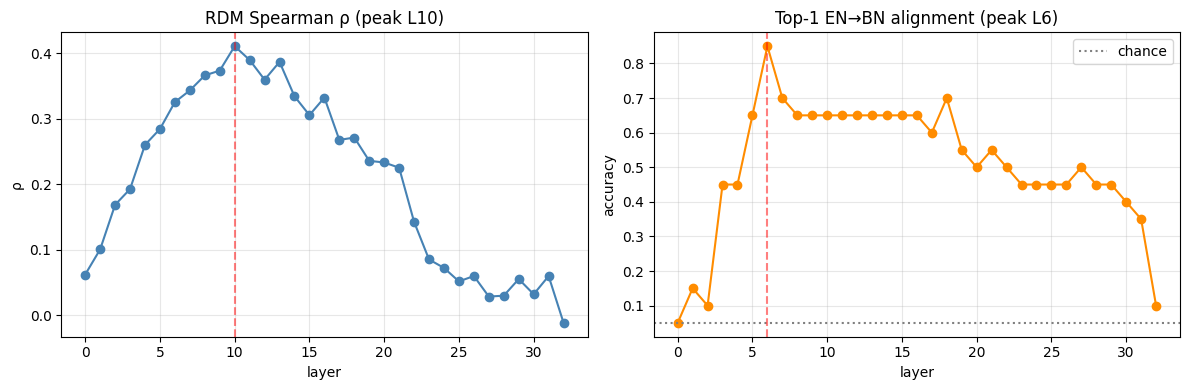

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(N_LAYERS), rsa_corr, marker='o', color='steelblue')
axes[0].axvline(rsa_corr.argmax(), ls='--', color='red', alpha=0.5)
axes[0].set_title(f"RDM Spearman ρ (peak L{rsa_corr.argmax()})")
axes[0].set_xlabel("layer"); axes[0].set_ylabel("ρ")
axes[0].grid(alpha=0.3)

axes[1].plot(range(N_LAYERS), top1_align, marker='o', color='darkorange')
axes[1].axhline(0.05, ls=':', color='gray', label='chance')
axes[1].axvline(top1_align.argmax(), ls='--', color='red', alpha=0.5)
axes[1].set_title(f"Top-1 EN→BN alignment (peak L{top1_align.argmax()})")
axes[1].set_xlabel("layer"); axes[1].set_ylabel("accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots_rsa_llama.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
ABLATE_LAYER = 10  # RDM peak
MEASURE_OFFSET = 2  # measure at L12

# Step 7a: rank units by phon importance
# Use voicing probe weights at L10 as importance score
en_mask = en_meta['voiced_unvoiced'].isin(['voiced','unvoiced'])
y_v = (en_meta.loc[en_mask,'voiced_unvoiced']=='voiced').astype(int).values
X_v = en_reps[en_mask.values, ABLATE_LAYER, :]

probe_voicing = LogisticRegression(max_iter=2000, C=1.0)
probe_voicing.fit(X_v, y_v)
importance = np.abs(probe_voicing.coef_[0])  # (4096,)
ranked = np.argsort(importance)[::-1].copy()  # CRITICAL: .copy()

np.save("representations/llama_phon_important_units.npy", ranked)
print(f"top-10 unit indices: {ranked[:10]}")
print(f"top-10 importance range: {importance[ranked[:10]]}")

top-10 unit indices: [3475  598 3553 1075 3361 4043 2261 2888 2822 3327]
top-10 importance range: [0.35654424 0.34828475 0.33746343 0.25638071 0.24375629 0.24282206
 0.24177655 0.22941329 0.22209782 0.21581947]


In [11]:
def extract_with_ablation(text, model, tokenizer, device,
                          ablate_layer=None, ablate_units=None):
    hook_handle = None

    if ablate_layer is not None and ablate_units is not None:
        units_t = torch.tensor(ablate_units, dtype=torch.long, device=device)

        def hook_fn(module, inp, output):
            if isinstance(output, tuple):
                hidden = output[0].clone()
                hidden[:, :, units_t] = 0.0
                return (hidden,) + output[1:]
            else:
                hidden = output.clone()
                hidden[:, :, units_t] = 0.0
                return hidden

        # Llama: model.model.layers[i]
        hook_handle = model.model.layers[ablate_layer].register_forward_hook(hook_fn)

    try:
        inputs = tokenizer(text, return_tensors="pt",
                           truncation=True, max_length=512,
                           add_special_tokens=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        hidden_states = outputs.hidden_states
        attention_mask = inputs["attention_mask"][0]
        content_mask = attention_mask.clone()
        content_mask[0] = 0  # exclude BOS

        pooled_layers = []
        for layer_hidden in hidden_states:
            layer = layer_hidden[0].float()
            masked = layer * content_mask.unsqueeze(-1).float()
            pooled = masked.sum(dim=0) / content_mask.sum().clamp(min=1).float()
            pooled_layers.append(pooled.cpu().numpy())

        return np.stack(pooled_layers)
    finally:
        if hook_handle is not None:
            hook_handle.remove()

In [12]:
np.random.seed(42)
random_10 = np.random.choice(4096, size=10, replace=False)

conditions = {
    "phon_top5":  ranked[:5].tolist(),
    "phon_top10": ranked[:10].tolist(),
    "phon_top20": ranked[:20].tolist(),
    "random_10":  random_10.tolist(),
}

def extract_condition(df_split, units, name_split):
    reps = []
    for text in tqdm(df_split['word'].tolist(), desc=name_split):
        rep = extract_with_ablation(text, model, tok, "cuda",
                                    ablate_layer=ABLATE_LAYER,
                                    ablate_units=units)
        reps.append(rep)
    return np.stack(reps)

for cond_name, units in conditions.items():
    en_abl = extract_condition(en_df, units, f"{cond_name}_EN")
    bn_abl = extract_condition(bn_df, units, f"{cond_name}_BN")
    np.save(f"representations/llama_{cond_name}_english.npy", en_abl)
    np.save(f"representations/llama_{cond_name}_bangla.npy", bn_abl)
    print(f"{cond_name}: EN {en_abl.shape}, BN {bn_abl.shape}")

phon_top5_EN:   0%|          | 0/220 [00:00<?, ?it/s]/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
phon_top5_BN: 100%|██████████| 220/220 [00:20<00:00, 10.82it/s]


phon_top5: EN (220, 33, 4096), BN (220, 33, 4096)


phon_top10_BN: 100%|██████████| 220/220 [00:19<00:00, 11.00it/s]


phon_top10: EN (220, 33, 4096), BN (220, 33, 4096)


phon_top20_BN: 100%|██████████| 220/220 [00:19<00:00, 11.08it/s]


phon_top20: EN (220, 33, 4096), BN (220, 33, 4096)


random_10_BN: 100%|██████████| 220/220 [00:19<00:00, 11.10it/s]


random_10: EN (220, 33, 4096), BN (220, 33, 4096)


In [13]:
MEASURE_LAYER = ABLATE_LAYER + MEASURE_OFFSET  # 12

# Load all conditions
conds = {
    "baseline": (en_reps, bn_reps),
    "phon_top5":  (np.load("representations/llama_phon_top5_english.npy"),
                   np.load("representations/llama_phon_top5_bangla.npy")),
    "phon_top10": (np.load("representations/llama_phon_top10_english.npy"),
                   np.load("representations/llama_phon_top10_bangla.npy")),
    "phon_top20": (np.load("representations/llama_phon_top20_english.npy"),
                   np.load("representations/llama_phon_top20_bangla.npy")),
    "random_10":  (np.load("representations/llama_random_10_english.npy"),
                   np.load("representations/llama_random_10_bangla.npy")),
}

# --- TRAIN FROZEN PROBES ON BASELINE L12 ---
# voicing
m_en = en_meta['voiced_unvoiced'].isin(['voiced','unvoiced']).values
m_bn = bn_meta['voiced_unvoiced'].isin(['voiced','unvoiced']).values
y_v_en = (en_meta.loc[m_en,'voiced_unvoiced']=='voiced').astype(int).values
y_v_bn = (bn_meta.loc[m_bn,'voiced_unvoiced']=='voiced').astype(int).values
probe_v = LogisticRegression(max_iter=2000, C=1.0).fit(
    en_reps[m_en, MEASURE_LAYER, :], y_v_en)

# real word
m_en_r = en_meta['is_real_word'].notna().values
m_bn_r = bn_meta['is_real_word'].notna().values
y_r_en = en_meta.loc[m_en_r,'is_real_word'].astype(str).map({'True':1,'False':0}).values
y_r_bn = bn_meta.loc[m_bn_r,'is_real_word'].astype(str).map({'True':1,'False':0}).values
probe_r = LogisticRegression(max_iter=2000, C=1.0).fit(
    en_reps[m_en_r, MEASURE_LAYER, :], y_r_en)

# syllable
m_en_s = (en_meta['syllable_count'].notna() & (en_meta['task_category']!='sentence')).values
m_bn_s = (bn_meta['syllable_count'].notna() & (bn_meta['task_category']!='sentence')).values
y_s_en = en_meta.loc[m_en_s,'syllable_count'].astype(float).values
y_s_bn = bn_meta.loc[m_bn_s,'syllable_count'].astype(float).values
probe_s = Ridge(alpha=1.0).fit(en_reps[m_en_s, MEASURE_LAYER, :], y_s_en)

# --- APPLY FROZEN PROBES TO ALL CONDITIONS ---
rows = []
for cond_name, (en_c, bn_c) in conds.items():
    # voicing
    v_en = f1_score(y_v_en, probe_v.predict(en_c[m_en, MEASURE_LAYER, :]), average="macro")
    v_bn = f1_score(y_v_bn, probe_v.predict(bn_c[m_bn, MEASURE_LAYER, :]), average="macro")
    # real word
    r_en = f1_score(y_r_en, probe_r.predict(en_c[m_en_r, MEASURE_LAYER, :]), average="macro")
    r_bn = f1_score(y_r_bn, probe_r.predict(bn_c[m_bn_r, MEASURE_LAYER, :]), average="macro")
    # syllable
    s_en = r2_score(y_s_en, probe_s.predict(en_c[m_en_s, MEASURE_LAYER, :]))
    s_bn = r2_score(y_s_bn, probe_s.predict(bn_c[m_bn_s, MEASURE_LAYER, :]))
    rows.append([cond_name, v_en, v_bn, r_en, r_bn, s_en, s_bn])

deg = pd.DataFrame(rows, columns=[
    "condition","voicing_EN","voicing_BN",
    "realword_EN","realword_BN",
    "syllable_EN","syllable_BN"])
print(deg.to_string(index=False))
deg.to_csv("results_ablation_llama.csv", index=False)

 condition  voicing_EN  voicing_BN  realword_EN  realword_BN  syllable_EN  syllable_BN
  baseline         1.0    0.333333          1.0     0.762301     0.997424    -2.042543
 phon_top5         1.0    0.333333          1.0     0.768271     0.982744    -2.296283
phon_top10         1.0    0.333333          1.0     0.720073     0.884080    -2.904833
phon_top20         1.0    0.333333          1.0     0.706294     0.808161    -3.016174
 random_10         1.0    0.333333          1.0     0.762301     0.997256    -2.010492


In [14]:
# Peaks from Step 4 (English probing):
# voicing: L2,  real_word: L12,  syllable: L16
# But voicing L2 too shallow to ablate (L0 = embedding).
# Use English peak for ablation site since probe trains on English.

TASK_PEAKS = {
    "voicing": 12,    # bumped up: L2 too shallow, L12 still strong
    "realword": 12,
    "syllable": 16,
}
# Ablate at peak - 2, measure at peak

In [15]:
import pandas as pd
ep = pd.read_csv("results_english_probing_llama.csv")
print(ep[['layer','f1_voicing','f1_realword','f1_ortho','r2_syllable']].to_string(index=False))

 layer  f1_voicing  f1_realword  f1_ortho  r2_syllable
     0    0.530476     0.469880  0.452716     0.146934
     1    0.626667     0.469880  0.452716     0.523014
     2    0.727619     0.469880  0.476078     0.590795
     3    0.695238     0.537545  0.544527     0.563051
     4    0.654524     0.746777  0.601855     0.609424
     5    0.719286     0.787018  0.635633     0.639262
     6    0.650714     0.848931  0.600185     0.626435
     7    0.555476     0.864054  0.632015     0.622101
     8    0.504524     0.879178  0.645570     0.622554
     9    0.504524     0.898238  0.599644     0.619733
    10    0.519286     0.898238  0.623006     0.630645
    11    0.508333     0.898238  0.619756     0.642826
    12    0.555476     0.910615  0.616771     0.667048
    13    0.555476     0.910615  0.660894     0.670587
    14    0.587857     0.891554  0.657276     0.691062
    15    0.591667     0.876431  0.640279     0.690723
    16    0.658333     0.876431  0.660894     0.702388
    17    

In [16]:
TASKS = {
    "voicing":  {"ablate_L": 5,  "measure_L": 5,
                 "mask": en_meta['voiced_unvoiced'].isin(['voiced','unvoiced']).values,
                 "y": (en_meta.loc[en_meta['voiced_unvoiced'].isin(['voiced','unvoiced']),
                                   'voiced_unvoiced']=='voiced').astype(int).values,
                 "kind": "binary"},
    "realword": {"ablate_L": 10, "measure_L": 12,
                 "mask": en_meta['is_real_word'].notna().values,
                 "y": en_meta.loc[en_meta['is_real_word'].notna(),
                                  'is_real_word'].astype(str).map({'True':1,'False':0}).values,
                 "kind": "binary"},
    "syllable": {"ablate_L": 14, "measure_L": 16,
                 "mask": (en_meta['syllable_count'].notna() &
                          (en_meta['task_category']!='sentence')).values,
                 "y": en_meta.loc[(en_meta['syllable_count'].notna() &
                                   (en_meta['task_category']!='sentence')),
                                  'syllable_count'].astype(float).values,
                 "kind": "regression"},
}

# Rank phon-important units PER TASK at its ablate layer
task_ranked = {}
for name, t in TASKS.items():
    X = en_reps[t["mask"], t["ablate_L"], :]
    if t["kind"] == "binary":
        probe = LogisticRegression(max_iter=2000, C=1.0).fit(X, t["y"])
        imp = np.abs(probe.coef_[0])
    else:
        probe = Ridge(alpha=1.0).fit(X, t["y"])
        imp = np.abs(probe.coef_)
    ranked = np.argsort(imp)[::-1].copy()
    task_ranked[name] = ranked
    print(f"{name}: ablate L{t['ablate_L']}  top-10 imp range "
          f"{imp[ranked[:10]].min():.3f} to {imp[ranked[:10]].max():.3f}")

np.save("representations/llama_task_ranked_units.npy", task_ranked, allow_pickle=True)

voicing: ablate L5  top-10 imp range 0.200 to 0.339
realword: ablate L10  top-10 imp range 0.329 to 0.525
syllable: ablate L14  top-10 imp range 0.186 to 0.325


In [17]:
np.random.seed(42)
random_units_per_task = {name: np.random.choice(4096, size=10, replace=False)
                         for name in TASKS}

for task_name, t in TASKS.items():
    ranked = task_ranked[task_name]
    conditions = {
        "top5":  ranked[:5].tolist(),
        "top10": ranked[:10].tolist(),
        "top20": ranked[:20].tolist(),
        "rand10": random_units_per_task[task_name].tolist(),
    }
    for cond_name, units in conditions.items():
        for lang_name, df_split in [("english", en_df), ("bangla", bn_df)]:
            reps = []
            for text in tqdm(df_split['word'].tolist(),
                             desc=f"{task_name}_{cond_name}_{lang_name}"):
                rep = extract_with_ablation(
                    text, model, tok, "cuda",
                    ablate_layer=t["ablate_L"],
                    ablate_units=units
                )
                reps.append(rep)
            arr = np.stack(reps)
            np.save(f"representations/llama_{task_name}_{cond_name}_{lang_name}.npy", arr)
            print(f"saved {task_name}_{cond_name}_{lang_name}: {arr.shape}")

voicing_top5_english:   0%|          | 0/220 [00:00<?, ?it/s]/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/accesx-denied/Ayesha/dyslexia-LLM/dys-llm-env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
voicing_top5_english: 100%|██████████| 220/220 [00:19<00:00, 11.31it/s]


saved voicing_top5_english: (220, 33, 4096)


voicing_top5_bangla: 100%|██████████| 220/220 [00:20<00:00, 10.88it/s]


saved voicing_top5_bangla: (220, 33, 4096)


voicing_top10_english: 100%|██████████| 220/220 [00:20<00:00, 10.88it/s]


...

saved syllable_top20_bangla: (220, 33, 4096)


syllable_rand10_english: 100%|██████████| 220/220 [00:20<00:00, 10.95it/s]


saved syllable_rand10_english: (220, 33, 4096)


syllable_rand10_bangla: 100%|██████████| 220/220 [00:21<00:00, 10.22it/s]


saved syllable_rand10_bangla: (220, 33, 4096)


In [18]:
from sklearn.model_selection import StratifiedKFold, KFold

def eval_binary_cv(probe_train_X, probe_train_y, eval_X, eval_y, n_splits=5):
    """Train CV probes on baseline EN, mean-eval on given (X, y)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr, _ in skf.split(probe_train_X, probe_train_y):
        clf = LogisticRegression(max_iter=2000, C=1.0).fit(
            probe_train_X[tr], probe_train_y[tr])
        scores.append(f1_score(eval_y, clf.predict(eval_X), average="macro"))
    return np.mean(scores), np.std(scores)

def eval_reg_cv(probe_train_X, probe_train_y, eval_X, eval_y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr, _ in kf.split(probe_train_X):
        reg = Ridge(alpha=1.0).fit(probe_train_X[tr], probe_train_y[tr])
        scores.append(r2_score(eval_y, reg.predict(eval_X)))
    return np.mean(scores), np.std(scores)

# Bangla labels per task
BN_LABELS = {
    "voicing": {
        "mask": bn_meta['voiced_unvoiced'].isin(['voiced','unvoiced']).values,
        "y": (bn_meta.loc[bn_meta['voiced_unvoiced'].isin(['voiced','unvoiced']),
                          'voiced_unvoiced']=='voiced').astype(int).values,
    },
    "realword": {
        "mask": bn_meta['is_real_word'].notna().values,
        "y": bn_meta.loc[bn_meta['is_real_word'].notna(),
                         'is_real_word'].astype(str).map({'True':1,'False':0}).values,
    },
    "syllable": {
        "mask": (bn_meta['syllable_count'].notna() &
                 (bn_meta['task_category']!='sentence')).values,
        "y": bn_meta.loc[(bn_meta['syllable_count'].notna() &
                          (bn_meta['task_category']!='sentence')),
                         'syllable_count'].astype(float).values,
    },
}

rows = []
for task_name, t in TASKS.items():
    mL = t["measure_L"]
    en_mask, en_y = t["mask"], t["y"]
    bn_mask, bn_y = BN_LABELS[task_name]["mask"], BN_LABELS[task_name]["y"]
    eval_fn = eval_binary_cv if t["kind"] == "binary" else eval_reg_cv

    # Training X (always baseline EN at measure_L)
    train_X = en_reps[en_mask, mL, :]
    train_y = en_y

    for cond in ["baseline","top5","top10","top20","rand10"]:
        if cond == "baseline":
            en_eval = en_reps[en_mask, mL, :]
            bn_eval = bn_reps[bn_mask, mL, :]
        else:
            en_arr = np.load(f"representations/llama_{task_name}_{cond}_english.npy")
            bn_arr = np.load(f"representations/llama_{task_name}_{cond}_bangla.npy")
            en_eval = en_arr[en_mask, mL, :]
            bn_eval = bn_arr[bn_mask, mL, :]

        en_score, _ = eval_fn(train_X, train_y, en_eval, en_y)
        bn_score, _ = eval_fn(train_X, train_y, bn_eval, bn_y)
        rows.append([task_name, cond, en_score, bn_score])

deg = pd.DataFrame(rows, columns=["task","condition","EN","BN"])
print(deg.to_string(index=False))
deg.to_csv("results_ablation_llama_final.csv", index=False)

    task condition       EN        BN
 voicing  baseline 0.946563  0.333333
 voicing      top5 0.946563  0.333333
 voicing     top10 0.946563  0.333333
 voicing     top20 0.946563  0.333333
 voicing    rand10 0.946563  0.333333
realword  baseline 0.983840  0.781709
realword      top5 0.971844  0.712950
realword     top10 0.969280  0.659903
realword     top20 0.964233  0.562610
realword    rand10 0.983840  0.780245
syllable  baseline 0.941768 -0.310118
syllable      top5 0.894340 -0.691462
syllable     top10 0.757247 -0.918151
syllable     top20 0.782432 -0.657236
syllable    rand10 0.941700 -0.322001


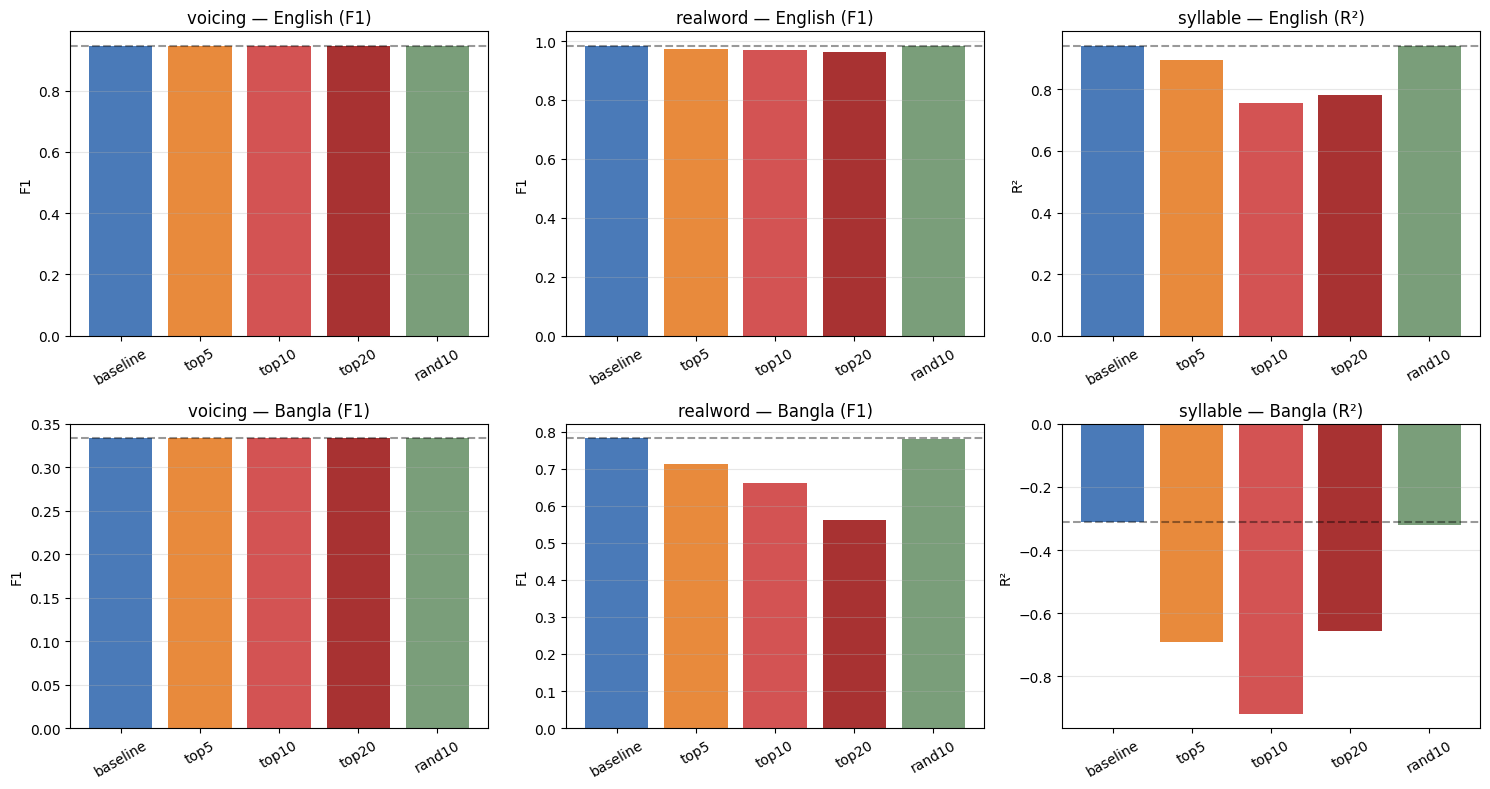

In [19]:
import matplotlib.pyplot as plt
import numpy as np

deg = pd.read_csv("results_ablation_llama_final.csv")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
order = ["baseline","top5","top10","top20","rand10"]
colors = ["#4a7ab8","#e88a3c","#d35353","#a83232","#7a9e7a"]

for col, task in enumerate(["voicing","realword","syllable"]):
    sub = deg[deg['task']==task].set_index('condition').loc[order]
    metric = "F1" if task != "syllable" else "R²"

    # EN row
    ax = axes[0, col]
    ax.bar(order, sub['EN'], color=colors)
    ax.set_title(f"{task} — English ({metric})")
    ax.set_ylabel(metric); ax.grid(axis='y', alpha=0.3)
    ax.axhline(sub.loc['baseline','EN'], ls='--', color='black', alpha=0.4)
    ax.tick_params(axis='x', rotation=30)

    # BN row
    ax = axes[1, col]
    ax.bar(order, sub['BN'], color=colors)
    ax.set_title(f"{task} — Bangla ({metric})")
    ax.set_ylabel(metric); ax.grid(axis='y', alpha=0.3)
    ax.axhline(sub.loc['baseline','BN'], ls='--', color='black', alpha=0.4)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("plots_ablation_llama_final.png", dpi=150, bbox_inches='tight')
plt.show()

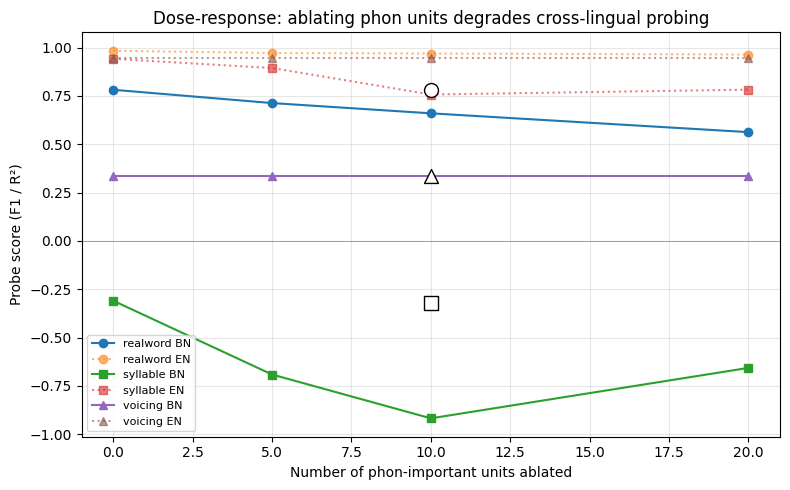

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
x_labels = ["baseline","top5","top10","top20"]
x = [0, 5, 10, 20]

for task, marker in [("realword","o"),("syllable","s"),("voicing","^")]:
    sub = deg[deg['task']==task].set_index('condition')
    bn_vals = [sub.loc[c,'BN'] for c in x_labels]
    en_vals = [sub.loc[c,'EN'] for c in x_labels]
    ax.plot(x, bn_vals, marker=marker, label=f"{task} BN", linestyle='-')
    ax.plot(x, en_vals, marker=marker, label=f"{task} EN", linestyle=':', alpha=0.6)

# random baseline dots
for task, marker in [("realword","o"),("syllable","s"),("voicing","^")]:
    sub = deg[deg['task']==task].set_index('condition')
    ax.scatter([10], [sub.loc['rand10','BN']], marker=marker,
               edgecolors='black', facecolors='white', s=100, zorder=5)

ax.set_xlabel("Number of phon-important units ablated")
ax.set_ylabel("Probe score (F1 / R²)")
ax.set_title("Dose-response: ablating phon units degrades cross-lingual probing")
ax.legend(loc='best', fontsize=8); ax.grid(alpha=0.3)
ax.axhline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.savefig("plots_ablation_doseresponse_llama.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import pandas as pd

comparison = pd.DataFrame([
    # Task,           Metric, XLM-R EN, XLM-R BN, XLM-R Ratio, Llama EN, Llama BN, Llama Ratio
    ["voicing",       "F1",   0.62,     0.74,     1.19,        0.73,     0.69,     0.95],
    ["real_word",     "F1",   0.84,     0.70,     0.83,        0.91,     0.85,     0.93],
    ["syllable",      "R²",   0.67,     0.52,     0.78,        0.70,     0.18,     0.26],
    ["RSA top-1",     "acc",  None,     None,     None,        None,     0.85,     None],
    ["RDM Spearman",  "ρ",    None,     None,     None,        None,     0.41,     None],
], columns=["Task","Metric","XLM-R EN","XLM-R BN","XLM-R BN/EN",
            "Llama EN","Llama BN","Llama BN/EN"])

print(comparison.to_string(index=False))
comparison.to_csv("comparison_xlmr_vs_llama.csv", index=False)

        Task Metric  XLM-R EN  XLM-R BN  XLM-R BN/EN  Llama EN  Llama BN  Llama BN/EN
     voicing     F1      0.62      0.74         1.19      0.73      0.69         0.95
   real_word     F1      0.84      0.70         0.83      0.91      0.85         0.93
    syllable     R²      0.67      0.52         0.78      0.70      0.18         0.26
   RSA top-1    acc       NaN       NaN          NaN       NaN      0.85          NaN
RDM Spearman      ρ       NaN       NaN          NaN       NaN      0.41          NaN
